In [9]:
import pandas as pd
from pathlib import Path
import json
from mistral_common.tokens.tokenizers.mistral import MistralTokenizer
import matplotlib.pyplot as plt

In [10]:
DATA_DIR = Path("data")
STATS_DIR = Path("stats")

In [11]:
most_recent_file = max(
    (f for f in STATS_DIR.iterdir() if f.suffix == ".json"),
    key=lambda f: f.stat().st_mtime
)

with open(most_recent_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# idee: ajouter au debut de chaque chunk titre + description (cat = summary)

In [12]:
summaries = [content for content, metadata_dict in data.items() if metadata_dict.get("cat") == "summary"]

In [13]:
# FIXME : utiliser tokenizer du LLM ou rester en "mots" puisque LLM pas definitif pour le moment ?

# https://docs.langchain.com/oss/python/integrations/splitters/split_by_token
# https://huggingface.co/mistralai/Mistral-Small-3.2-24B-Instruct-2506

def count_nb_tokens(text):
    model_id = "mistralai/Mistral-Small-3.2-24B-Instruct-2506"
    tokenizer = MistralTokenizer.from_hf_hub(model_id)
    return len(tokenizer.instruct_tokenizer.tokenizer.encode(text, bos=False, eos=False))

df_summary_token_count = pd.DataFrame(summaries, columns=["summary"])
df_summary_token_count["token_count"] = df_summary_token_count["summary"].apply(count_nb_tokens)

In [14]:
# FIXME / TODO : montrer au prof
# FIXME : approximation des mots pour des tokens ok ou completement ko ? -> nb mots = 70% de nb tokens en moyenne donc ko ?

df_summary_token_count["word_count"] = df_summary_token_count["summary"].apply(lambda x: len(x.split()))
df_summary_token_count["ration_words_tokens"] = df_summary_token_count["word_count"] / df_summary_token_count["token_count"]
df_summary_token_count["char_count"] = df_summary_token_count["summary"].apply(len)

df_summary_token_count

,summary,token_count,word_count,ration_words_tokens,char_count
0,Loi fédérale sur les écoles polytechniques féd...,76,52,0.684211,366
1,Federal Act on the Federal Institutes of Techn...,60,52,0.866667,353
2,Ordonnance sur le domaine des écoles polytechn...,33,23,0.696970,150
3,Ordonnance sur le domaine des écoles polytechn...,30,21,0.700000,156
4,Ordonnance du Conseil des EPF sur les écoles p...,55,38,0.690909,219
...,...,...,...,...,...
331,Directive concernant la Commission du Personne...,98,75,0.765306,509
332,Directive concerning the Staff Commission of t...,86,66,0.767442,455
333,Ordonnance du Conseil des hautes écoles sur l’...,102,70,0.686275,499
334,Ordonnance du Conseil des hautes écoles sur l’...,87,64,0.735632,480


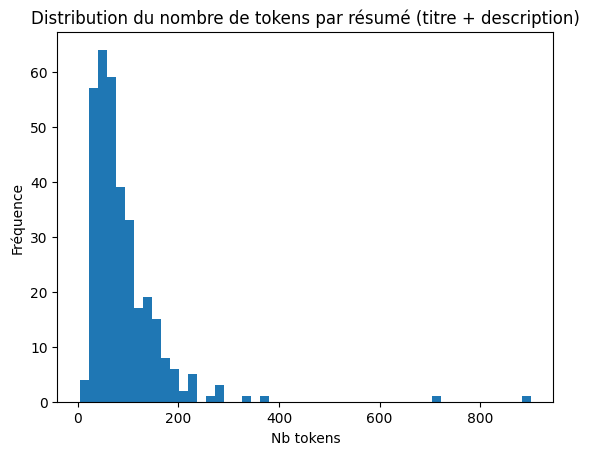

In [15]:
plt.hist(df_summary_token_count["token_count"], bins=50)
plt.xlabel("Nb tokens")
plt.ylabel("Fréquence")
plt.title("Distribution du nombre de tokens par résumé (titre + description)")
plt.show()

In [16]:
# contrainte: taille du contenu trop important ?
# FIXME : quel est le pourcentage max a "assigner" a ce contenu dans un chunk ?
# FIXME : quelle est la taille max d'un chunk
# FIXME : depend de la taille de contexte du LLM mais aussi du nombre de chunks retrieved...
# FIXME : https://huggingface.co/mistralai/Mistral-Small-3.2-24B-Instruct-2506 -> 128K tokens pour input + output donc comment estimer la taille d'input idéale (+ mieux de faire "court" pour ne pas se perdre en chemin...)

# alternative: ajouter au debut de chaque chunk uniquement le titre et ne pas indexer du tout les "summary"